# **Tutorial:** Custom YOLO Object Detection with RoboFlow

In this tutorial, you'll learn how to create a custom YOLO object detection model using your own classes and annotations with RoboFlow.

### **Step 1: Install Required Dependencies**

In [1]:
%pip install --upgrade ultralytics
%pip install opencv-python
%pip install roboflow
%pip install matplotlib
%pip install numpy==1.26.4 --force-reinstall

     ---------------------------------------- 1.2/1.2 MB 4.5 MB/s eta 0:00:00
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.4.22
    Uninstalling ultralytics-8.4.22:
      Successfully uninstalled ultralytics-8.4.22
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached numpy-1.26.4-cp311-cp311-win_amd64.whl (15.8 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inference-sdk 1.1.1 requires numpy<2.4.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.

[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### **Step 2: Import Required Libraries**

In [2]:
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

### **Step 3: Set Up RoboFlow Account**

1. Go to RoboFlow and create a free account
2. Create a new project and select "Object Detection" as project type
3. Choose "YOLOv26" as the model format

### **Step 4: Upload and Annotate Your Images**

#### Using RoboFlow Web Interface:

1. Click "Upload" to add your images
2. Use the annotation tool to draw bounding boxes around objects
3. Assign the correct class labels to each bounding box
4. Apply preprocessing and augmentation as needed

### **Step 5. Download your Custom your Dataset**

1. In RoboFlow, go to your project dashboard
2. Click "Generate" to create a dataset version
3. Apply any desired augmentations
4. Click "Export" and select "YOLOv**x**" format (**x** the version you are using)
5. Copy the download code

In [2]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="VH6pE58CCoJQsGACfePl")
project = rf.workspace("marcks-workspace").project("find-eraser")
version = project.version(9)
dataset = version.download("yolo26")
                


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to find-eraser-9 in yolo26:: 100%|██████████| 277/277 [00:00<00:00, 367.24it/s]


### **Step 6: Train Your Custom YOLO Model**

In [4]:
# Load the YOLO model with custom configuration
model = YOLO('yolo26n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=50,  # Number of training epochs
    imgsz=640,  # Image size
    batch=16,   # Batch size
    name='custom_yolo_model'  # Name for the training run
)

New https://pypi.org/project/ultralytics/8.4.23 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.22  Python-3.11.0 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\find-eraser-9/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937,

### **Step 7: Evaluate Your Model**

In [5]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

# Show some validation results
!yolo task=detect mode=val model=runs/detect/custom_yolo_model/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.22  Python-3.11.0 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 33.814.8 MB/s, size: 4.7 KB)
val: Scanning C:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\find-eraser-9\valid\labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16  0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 15, len(boxes) = 20. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4s/it 1.4s
                   all         16         20      0.859      0.744      0.821      0.682
                eraser         12         15      0.774      0.688      0.802      0.714
            sa

### **Step 8: Test Your Custom Model on an Image**

In [ ]:
# Load your custom trained model
custom_model = YOLO('/Users/eugenio/Documents/Notebooks_ArtificialIntelligence/runs/detect/custom_yolo_model/weights/best.pt')

# Test on a sample image
results = custom_model('/Users/eugenio/Documents/Notebooks_ArtificialIntelligence/5. Computer Vision/Object Detection/taza_test.jpg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

### **Step 9: Test Your Custom Model on Video**

In [3]:
%pip install -U inference-sdk

  Using cached numpy-2.3.5-cp311-cp311-win_amd64.whl (13.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 5] Acceso denegado: 'C:\\Users\\User\\AppData\\Local\\Programs\\Python\\Python311\\Lib\\site-packages\\~umpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install roboflow



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**LAB**


In [1]:
import cv2
from roboflow import Roboflow
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import Image, display

In [5]:
from roboflow import Roboflow
rf = Roboflow(api_key="VH6pE58CCoJQsGACfePl")
project = rf.workspace("marcks-workspace").project("lab4_3")
version = project.version(12)
dataset = version.download("yolov8")
                

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
# Load the YOLO model with custom configuration
model = YOLO('yolov8n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=100,  # Number of training epochs
    imgsz=640,  # Image size
    batch=16,   # Batch size
    name='custom_yolo_model'  # Name for the training run
)

Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\Lab4_3-12/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_model3, nbs=64, nms=False, opset=None, optimize=False, o

In [ ]:
# Evaluate model performance
metrics = model.val()  # Validate the model
print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")

# Show some validation results
!yolo task=detect mode=val model=runs/detect/custom_yolo_model2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 114.945.1 MB/s, size: 9.4 KB)
val: Scanning C:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\Lab4_3-12\valid\labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 16/16  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3s/it 1.3s
                   all         16         17      0.991      0.929      0.986      0.949
                 gorra         10         10      0.992          1      0.995      0.995
            sacapuntas          6          7      0.991      0.857      0.978      0.903
Speed: 1.1ms preprocess, 75.3ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\runs\detect\val
mAP50-95: 0.9487961397058825
m


image 1/1 c:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\test2.jpeg: 640x480 1 sacapuntas, 121.9ms
Speed: 7.0ms preprocess, 121.9ms inference, 11.3ms postprocess per image at shape (1, 3, 640, 480)


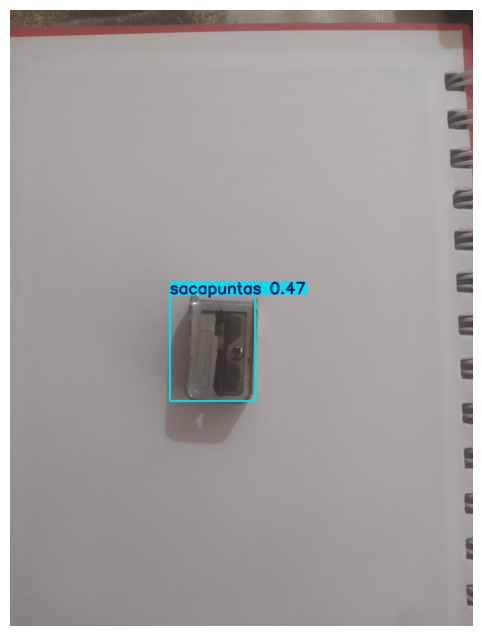

In [2]:
# Load your custom trained model
custom_model = YOLO('runs/detect/custom_yolo_model2/weights/best.pt')

# Test on a sample image
results = custom_model('test2.jpeg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()


image 1/1 c:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\test1.jpeg: 640x480 1 gorra, 101.9ms
Speed: 8.6ms preprocess, 101.9ms inference, 10.2ms postprocess per image at shape (1, 3, 640, 480)


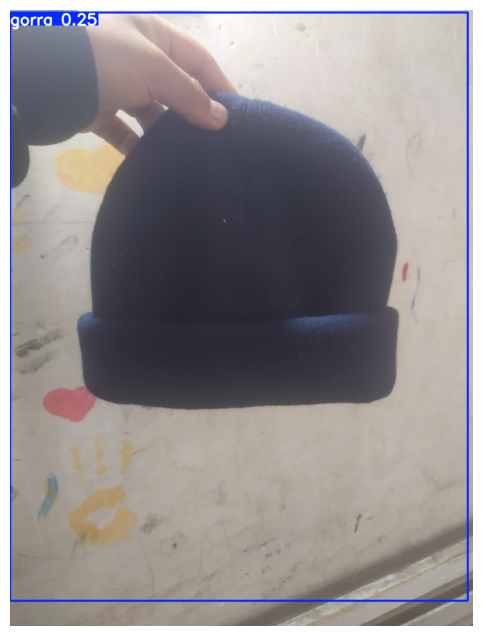

In [ ]:
# Load your custom trained model
custom_model = YOLO('runs/detect/custom_yolo_model2/weights/best.pt')

# Test on a sample image
results = custom_model('test1.jpeg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [ ]:
import cv2
from ultralytics import YOLO

model = YOLO('runs/detect/custom_yolo_model2/weights/best.pt')

cap = cv2.VideoCapture("videotest.mp4")

# Obtener propiedades del video
width = int(cap.get(3))
height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Crear writer
out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (width, height)
)

while cap.isOpened():
    ret, frame = cap.read()
    
    if not ret:
        break

    results = model(frame, conf=0.25)
    annotated_frame = results[0].plot()

    out.write(annotated_frame)

    cv2.imshow("Video Detection", annotated_frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
out.release()
cv2.destroyAllWindows()


0: 640x384 1 gorra, 47.4ms
Speed: 2.5ms preprocess, 47.4ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 42.7ms
Speed: 2.1ms preprocess, 42.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 41.0ms
Speed: 1.6ms preprocess, 41.0ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 45.6ms
Speed: 1.7ms preprocess, 45.6ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 41.3ms
Speed: 1.8ms preprocess, 41.3ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 40.5ms
Speed: 1.9ms preprocess, 40.5ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 39.1ms
Speed: 1.8ms preprocess, 39.1ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 gorra, 36.1ms
Speed: 1.5ms preprocess, 36.1ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 384)


In [ ]:
# Cargar tu modelo entrenado
model = YOLO("runs/detect/custom_yolo_model2/weights/best.pt")

# Abrir cámara (0 = webcam)
cap = cv2.VideoCapture(1)

while True:
    ret, frame = cap.read()
    
    if not ret:
        print("Error al acceder a la cámara")
        break

    # Detección
    results = model(frame, conf=0.25)

    # Dibujar resultados
    annotated_frame = results[0].plot()

    # Mostrar
    cv2.imshow("Real-Time Detection", annotated_frame)

    # Salir con Q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Liberar recursos
cap.release()
cv2.destroyAllWindows()


0: 480x640 1 gorra, 66.7ms
Speed: 13.0ms preprocess, 66.7ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 50.8ms
Speed: 5.1ms preprocess, 50.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 51.9ms
Speed: 2.0ms preprocess, 51.9ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 44.8ms
Speed: 1.4ms preprocess, 44.8ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 47.0ms
Speed: 1.8ms preprocess, 47.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 51.0ms
Speed: 1.7ms preprocess, 51.0ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 50.0ms
Speed: 1.3ms preprocess, 50.0ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 gorra, 43.5ms
Speed: 1.2ms preprocess, 43.5ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)

In [9]:
import cv2
from ultralytics import YOLO

# 1. Configuración
model = YOLO('runs/detect/custom_yolo_model2/weights/best.pt')
# REEMPLAZA ESTA IP CON LA QUE VES EN TU CELULAR AHORA MISMO
url = "http://192.168.1.103:4747/video" 

# 2. Intentar la conexión
cap = cv2.VideoCapture(url)

# Configurar un tiempo de espera para que no se congele el Kernel si falla
cap.set(cv2.CAP_PROP_BUFFERSIZE, 1) 

if not cap.isOpened():
    print("--- ERROR DE CONEXIÓN ---")
    print("1. Verifica que cerraste el programa DroidCam en Windows.")
    print("2. Verifica que la IP en el celular coincida con la del código.")
    print("3. Intenta poner la IP en tu navegador (Chrome) para ver si carga.")
else:
    print("¡Conectado con éxito! Presiona 'q' para salir.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Se perdió la conexión con el celular.")
            break

        # Redimensionar para fluidez (opcional pero recomendado)
        frame = cv2.resize(frame, (640, 480))

        # Inferencia
        results = model(frame, conf=0.3, verbose=False)
        annotated_frame = results[0].plot()

        # Mostrar video
        cv2.imshow("Deteccion YOLO - Control Directo", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    print("Proceso finalizado.")

¡Conectado con éxito! Presiona 'q' para salir.
Proceso finalizado.


Prueba


In [2]:
from roboflow import Roboflow
rf = Roboflow(api_key="VH6pE58CCoJQsGACfePl")
project = rf.workspace("marcks-workspace").project("lab4_3")
version = project.version(13)
dataset = version.download("yolo26")
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lab4_3-13 in yolo26:: 100%|██████████| 287/287 [00:00<00:00, 1083.31it/s]


In [4]:
# Load the YOLO model with custom configuration
model = YOLO('yolo26n.pt')  # Using nano version as base

# Train the model on your custom dataset
results = model.train(
    data=f'{dataset.location}/data.yaml',  # Path to dataset config
    epochs=100,  # Number of training epochs
    imgsz=640,  # Image size
    batch=16,   # Batch size
    name='custom_yolo_model26'  # Name for the training run
)

Ultralytics 8.4.23  Python-3.11.0 torch-2.10.0+cpu CPU (12th Gen Intel Core i7-12700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\Lab4_3-13/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_yolo_model26, nbs=64, nms=False, opset=None, optimize=False, 


image 1/1 c:\Users\User\Documents\ANTHONY\NOVENO\VISION\Lab_4\test3.jpeg: 640x384 1 sacapuntas, 57.3ms
Speed: 2.1ms preprocess, 57.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 384)


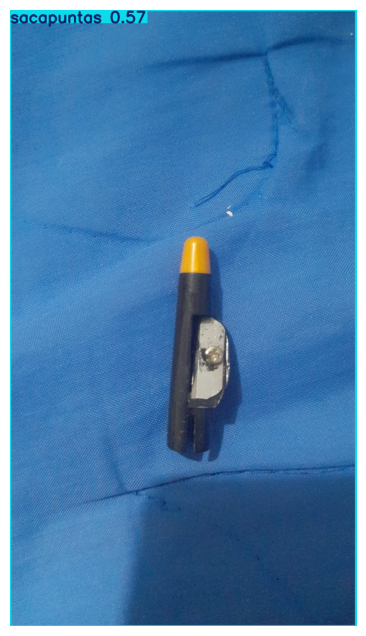

In [6]:
# Load your custom trained model
custom_model = YOLO('runs/detect/custom_yolo_model26/weights/best.pt')

# Test on a sample image
results = custom_model('test3.jpeg', conf=0.25)

# Display results
%matplotlib inline
for result in results:
    img = result.plot()  # Plot detections
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.show()

In [7]:
import cv2
from ultralytics import YOLO

# 1. Configuración
model = YOLO('runs/detect/custom_yolo_model26/weights/best.pt')
# REEMPLAZA ESTA IP CON LA QUE VES EN TU CELULAR AHORA MISMO
url = "http://192.168.1.103:4747/video" 

# 2. Intentar la conexión
cap = cv2.VideoCapture(url)

# Configurar un tiempo de espera para que no se congele el Kernel si falla
cap.set(cv2.CAP_PROP_BUFFERSIZE, 1) 

if not cap.isOpened():
    print("--- ERROR DE CONEXIÓN ---")
    print("1. Verifica que cerraste el programa DroidCam en Windows.")
    print("2. Verifica que la IP en el celular coincida con la del código.")
    print("3. Intenta poner la IP en tu navegador (Chrome) para ver si carga.")
else:
    print("¡Conectado con éxito! Presiona 'q' para salir.")

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Se perdió la conexión con el celular.")
            break

        # Redimensionar para fluidez (opcional pero recomendado)
        frame = cv2.resize(frame, (640, 480))

        # Inferencia
        results = model(frame, conf=0.3, verbose=False)
        annotated_frame = results[0].plot()

        # Mostrar video
        cv2.imshow("Deteccion YOLO - Control Directo", annotated_frame)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
finally:
    cap.release()
    cv2.destroyAllWindows()
    print("Proceso finalizado.")

¡Conectado con éxito! Presiona 'q' para salir.
Proceso finalizado.


## **Activity: Create Your Custom Detector**

1. **Create a RoboFlow account** and set up a new project
2. **Upload at least 20 images** of your custom objects (at least 2)
3. **Annotate all images** with bounding boxes and class labels
4. **Train a YOLO model** on your custom dataset
5. **Test your model** on new images and evaluate its performance
6. **Implement real-time detection** with your custom classes

## **Grading Rubric:**

| **Criteria** | **Points** | **Description** |
|-------------|-----------|----------------|
| **1. Dataset Creation** | 3 | Successfully creates and annotates a custom dataset with at least 25 images and multiple classes in RoboFlow. |
| **2. Model Training** | 3 | Properly trains a YOLOv8 model on the custom dataset with appropriate hyperparameters. |
| **3. Model Evaluation** | 2 | Evaluates model performance with appropriate metrics and provides analysis of results. |
| **4. Custom Detection** | 2 | Implements real-time detection with custom classes and displays results correctly. |
| **5. Documentation** | 1 | Provides clear documentation of the process, including dataset details and model performance. |

**Total: 10 points**

## **Tips for Success:**

- **Quality over quantity**: Well-annotated images are more important than many poorly annotated ones
- **Class balance**: Try to have a similar number of examples for each class
- **Variety**: Include different angles, lighting conditions, and backgrounds
- **Augmentation**: Use RoboFlow's augmentation features to expand your dataset

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>